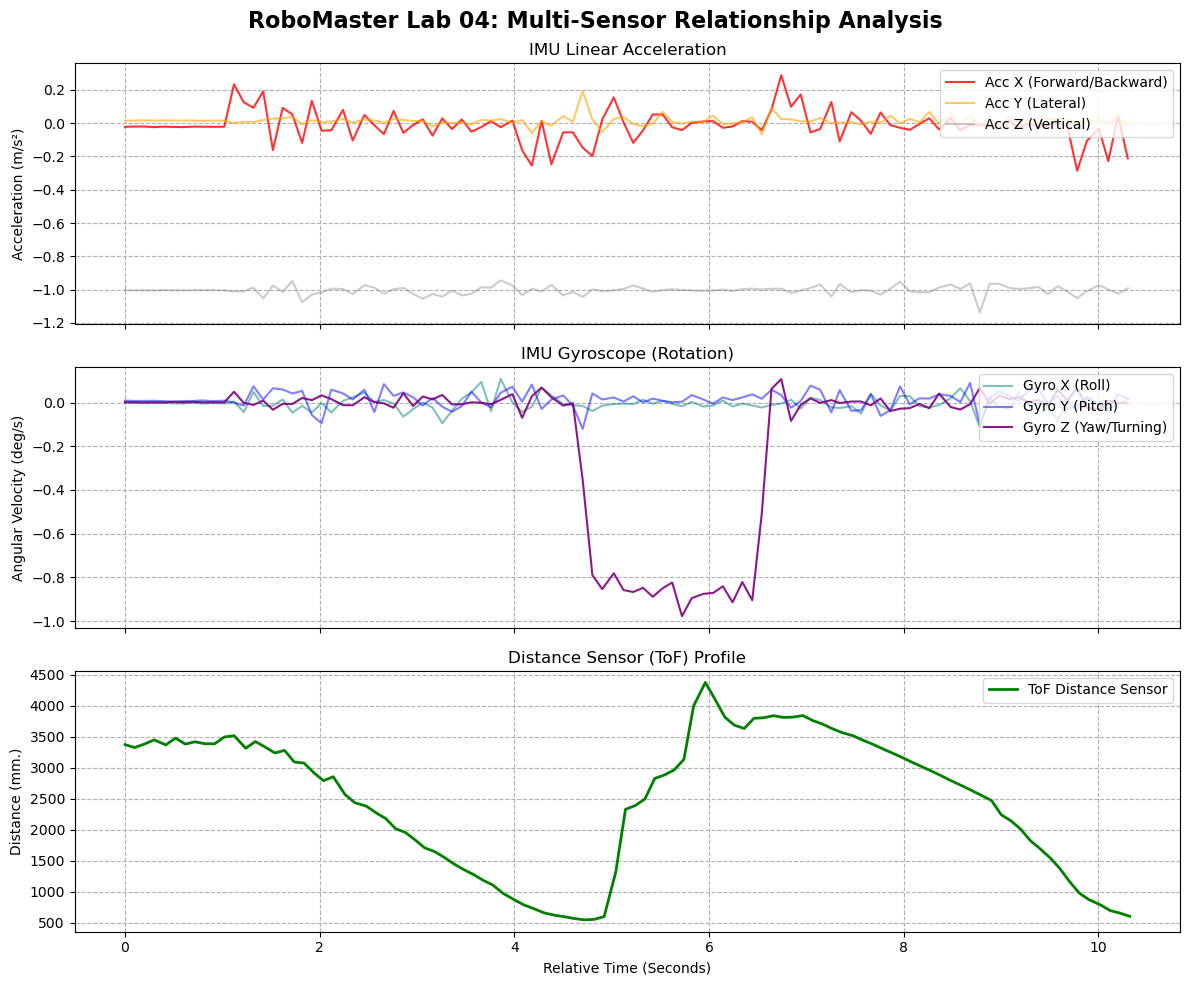

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. อ่านข้อมูลจากไฟล์ CSV ทั้ง 3 ตัวที่เก็บไว้ในโฟลเดอร์ aj_sahapong/lab4
df_acc = pd.read_csv('/Users/nannam/Downloads/robo/RoboMaster-SDK/aj_sahapong/lab4/ACC.csv')
df_gyro = pd.read_csv('/Users/nannam/Downloads/robo/RoboMaster-SDK/aj_sahapong/lab4/GYRO.csv')
df_dist = pd.read_csv('/Users/nannam/Downloads/robo/RoboMaster-SDK/aj_sahapong/lab4/Distance.csv')

# 2. ทำ Time Alignment: แปลง Unix Timestamp (ms) ให้เป็น วินาทีสัมพัทธ์ (เริ่มจาก 0)
# หาจุดเวลาเริ่มต้นที่เร็วที่สุดในบรรดาทุกเซนเซอร์เพื่อเป็นจุดอ้างอิงฐานเวลา (T=0)
start_time = min(df_acc['Time'].iloc[0], df_gyro['Time'].iloc[0], df_dist['Time'].iloc[0])

df_acc['time_sec'] = (df_acc['Time'] - start_time) / 1000
df_gyro['time_sec'] = (df_gyro['Time'] - start_time) / 1000
df_dist['time_sec'] = (df_dist['Time'] - start_time) / 1000

# 3. สร้างหน้าต่างกราฟ 3 ชั้น (3 Subplots) ที่ใช้แกน X (เวลา) ร่วมกัน
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle('RoboMaster Lab 04: Multi-Sensor Relationship Analysis', fontsize=16, fontweight='bold')

# --- ชั้นที่ 1: พลอต ความเร่ง (Acceleration จาก ACC.csv) ---
axs[0].plot(df_acc['time_sec'], df_acc['acc_x'], label='Acc X (Forward/Backward)', color='red', alpha=0.8)
axs[0].plot(df_acc['time_sec'], df_acc['acc_y'], label='Acc Y (Lateral)', color='orange', alpha=0.6)
axs[0].plot(df_acc['time_sec'], df_acc['acc_z'], label='Acc Z (Vertical)', color='gray', alpha=0.4)
axs[0].set_ylabel('Acceleration (m/s²)')
axs[0].set_title('IMU Linear Acceleration')
axs[0].grid(True, linestyle='--')
axs[0].legend(loc='upper right')

# --- ชั้นที่ 2: พลอต ความเร็วเชิงมุม (Gyroscope จาก GYRO.csv) ---
axs[1].plot(df_gyro['time_sec'], df_gyro['gyro_x'], label='Gyro X (Roll)', color='teal', alpha=0.5)
axs[1].plot(df_gyro['time_sec'], df_gyro['gyro_y'], label='Gyro Y (Pitch)', color='blue', alpha=0.5)
axs[1].plot(df_gyro['time_sec'], df_gyro['gyro_z'], label='Gyro Z (Yaw/Turning)', color='purple', alpha=0.9)
axs[1].set_ylabel('Angular Velocity (deg/s)')
axs[1].set_title('IMU Gyroscope (Rotation)')
axs[1].grid(True, linestyle='--')
axs[1].legend(loc='upper right')

# --- ชั้นที่ 3: พลอต ระยะทาง ToF (Distance จาก Distance.csv) ---
axs[2].plot(df_dist['time_sec'], df_dist['Distance(mm.)'], label='ToF Distance Sensor', color='green', linewidth=2)
axs[2].set_ylabel('Distance (mm.)')
axs[2].set_xlabel('Relative Time (Seconds)')
axs[2].set_title('Distance Sensor (ToF) Profile')
axs[2].grid(True, linestyle='--')
axs[2].legend(loc='upper right')

# จัดระเบียบหน้าตาและบันทึกรูปภาพ
plt.tight_layout()
plt.show()